In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve
)
from scipy.stats import chi2_contingency
import mlflow
import mlflow.sklearn
from datetime import datetime
import joblib
import json

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load Preprocessed Data from Part A

In [2]:
# Load the cleaned dataset (replace 'Akampa' with your last name)
clean_data = pd.read_csv('Akampa.csv')

# Separate features and target
X_processed = clean_data.drop('target', axis=1)
y = clean_data['target']

# Train-test split (same as Part A)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Data loaded successfully")
print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

✓ Data loaded successfully
Training set: (700, 48)
Test set: (300, 48)


# 1. Model Selection & Justification (8 marks)

## Chosen Model: **Logistic Regression** (Classical ML - Classification)

### Justification:

1. **Hypothesis Alignment**: Binary classification problem (default vs non-default) matches logistic regression's strength
2. **Data Size**: ~1,000 samples is appropriate for classical ML; deep learning would risk overfitting
3. **Interpretability**: Financial institutions require explainable decisions for regulatory compliance
4. **Ethical Considerations**: Transparent coefficients enable bias detection and fairness auditing
5. **Computational Efficiency**: Fast training and prediction for real-time credit decisions

> 💡 **Note**: While ensemble methods (Random Forest, XGBoost) might yield higher accuracy, interpretability is prioritized for credit scoring compliance.

# 2. Model Development & Experiment Tracking (10 marks)

In [3]:
# Set up MLflow experiment tracking
mlflow.set_experiment("Credit_Risk_Prediction")

# Start MLflow run
mlflow.start_run(run_name=f"LogisticRegression_baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}")

# Train baseline Logistic Regression
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

logreg.fit(X_train_scaled, y_train)

# Log parameters to MLflow
mlflow.log_param("model_type", "Logistic Regression")
mlflow.log_param("class_weight", "balanced")
mlflow.log_param("max_iter", 1000)
mlflow.log_param("solver", "lbfgs")
mlflow.log_param("train_size", X_train_scaled.shape[0])
mlflow.log_param("test_size", X_test_scaled.shape[0])
mlflow.log_param("n_features", X_train_scaled.shape[1])

print("✓ Baseline model trained with MLflow tracking!")
print(f"Number of features: {len(logreg.coef_[0])}")
print(f"Intercept: {logreg.intercept_[0]:.4f}")

2025/12/14 23:10:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/14 23:10:37 INFO mlflow.store.db.utils: Updating database tables
2025/12/14 23:10:37 INFO mlflow.store.db.utils: Updating database tables
2025/12/14 23:10:37 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/14 23:10:37 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/14 23:10:37 INFO mlflow.tracking.fluent: Experiment with name 'Credit_Risk_Prediction' does not exi

✓ Baseline model trained with MLflow tracking!
Number of features: 48
Intercept: -0.4304


## Initial Model Evaluation

In [4]:
# Make predictions
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)
y_train_pred_proba = logreg.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("=== BASELINE MODEL PERFORMANCE ===")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1: {test_f1:.4f}")

# Log metrics to MLflow
mlflow.log_metric("train_auc", train_auc)
mlflow.log_metric("test_auc", test_auc)
mlflow.log_metric("test_accuracy", test_accuracy)
mlflow.log_metric("test_precision", test_precision)
mlflow.log_metric("test_recall", test_recall)
mlflow.log_metric("test_f1", test_f1)

=== BASELINE MODEL PERFORMANCE ===
Train AUC: 0.8334
Test AUC: 0.7982
Test Accuracy: 0.7300
Test Precision: 0.5354
Test Recall: 0.7556
Test F1: 0.6267


## Confusion Matrix Visualization

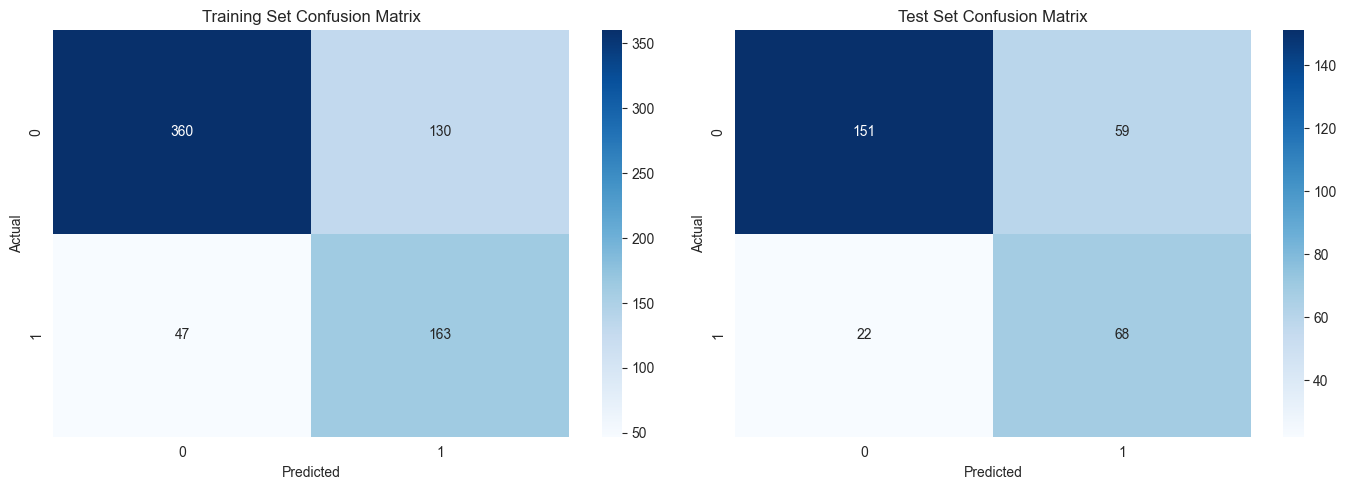

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Test Set Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## ROC Curve

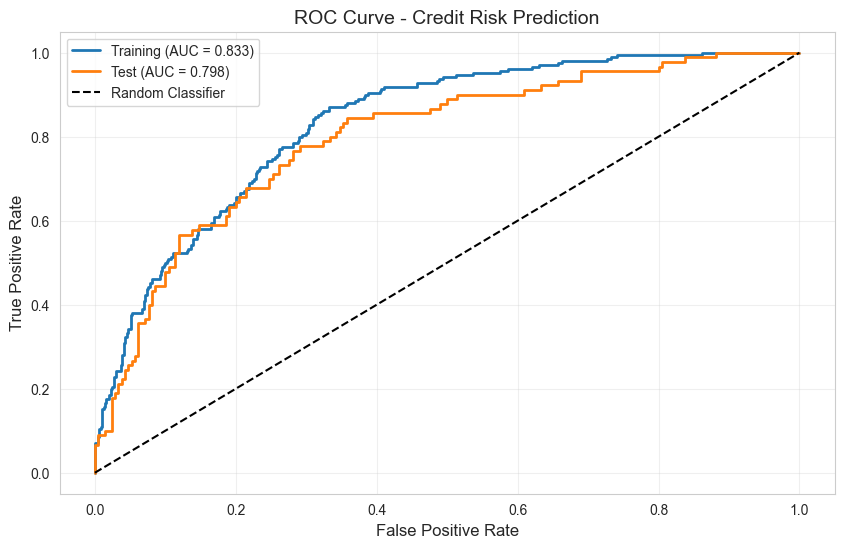

In [6]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {train_auc:.3f})', linewidth=2)
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Credit Risk Prediction', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Save and log to MLflow
roc_plot_path = "roc_curve.png"
plt.savefig(roc_plot_path, dpi=150, bbox_inches='tight')
mlflow.log_artifact(roc_plot_path)
plt.show()

## Feature Importance Analysis

=== Top 15 Most Important Features ===
                                          feature  coefficient
9                     checking_status_no checking    -0.693466
10  credit_history_critical/other existing credit    -0.618693
42                                   housing_rent     0.394921
39                       other_payment_plans_none    -0.386779
0                                        duration     0.370488
36           property_magnitude_no known property     0.339644
47                             foreign_worker_yes     0.331210
2                          installment_commitment     0.324400
5                                existing_credits     0.276484
17                              purpose_education     0.274293
27                              employment_4<=X<7    -0.266278
33                    personal_status_male single    -0.244744
24                            savings_status_<100     0.237748
34                        other_parties_guarantor    -0.237685
25              

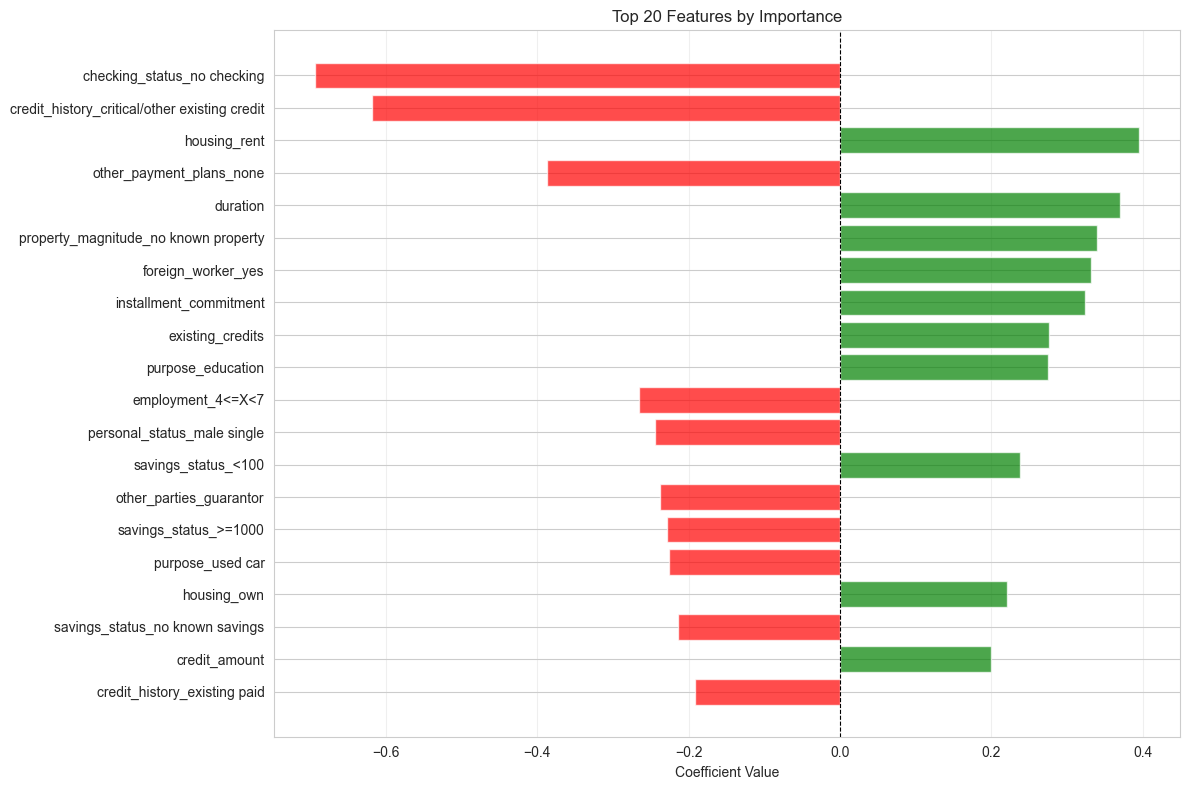


✓ Positive coefficients (green) increase default risk
✓ Negative coefficients (red) decrease default risk


In [7]:
# Extract feature coefficients
feature_importance = pd.DataFrame({
    'feature': X_processed.columns,
    'coefficient': logreg.coef_[0]
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance_sorted = feature_importance.sort_values('abs_coefficient', ascending=False)

print("=== Top 15 Most Important Features ===")
print(feature_importance_sorted.head(15)[['feature', 'coefficient']])

# Visualize top 20
top_features = feature_importance_sorted.head(20)
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 20 Features by Importance')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Positive coefficients (green) increase default risk")
print("✓ Negative coefficients (red) decrease default risk")

## Cross-Validation

=== 5-FOLD CROSS-VALIDATION RESULTS ===

Accuracy:  0.6943 (+/- 0.0159)
ROC-AUC:   0.7585 (+/- 0.0238)
F1 Score:  0.5679 (+/- 0.0284)
Precision: 0.4930 (+/- 0.0195)
Recall:    0.6714 (+/- 0.0530)


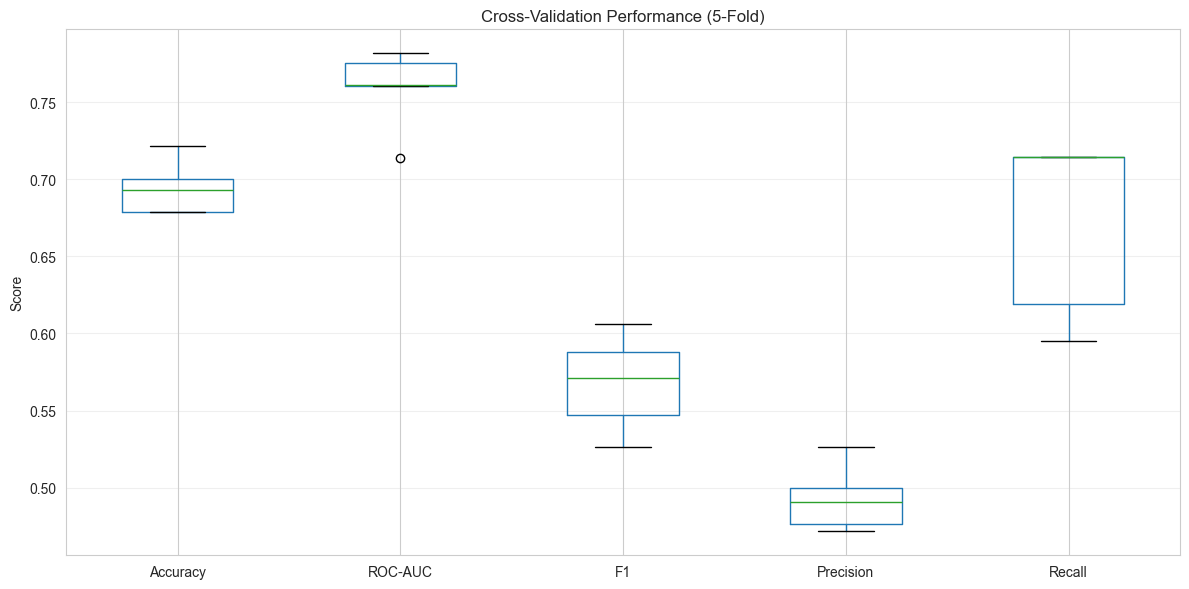

In [8]:
# 5-fold cross-validation
cv_scores = cross_validate(
    logreg, X_train_scaled, y_train,
    cv=5,
    scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

print("=== 5-FOLD CROSS-VALIDATION RESULTS ===\n")
print(f"Accuracy:  {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
print(f"ROC-AUC:   {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")
print(f"F1 Score:  {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
print(f"Precision: {cv_scores['test_precision'].mean():.4f} (+/- {cv_scores['test_precision'].std():.4f})")
print(f"Recall:    {cv_scores['test_recall'].mean():.4f} (+/- {cv_scores['test_recall'].std():.4f})")

# Log to MLflow
mlflow.log_metric("cv_accuracy_mean", cv_scores['test_accuracy'].mean())
mlflow.log_metric("cv_auc_mean", cv_scores['test_roc_auc'].mean())
mlflow.log_metric("cv_f1_mean", cv_scores['test_f1'].mean())

# Visualize
cv_results_df = pd.DataFrame({
    'Accuracy': cv_scores['test_accuracy'],
    'ROC-AUC': cv_scores['test_roc_auc'],
    'F1': cv_scores['test_f1'],
    'Precision': cv_scores['test_precision'],
    'Recall': cv_scores['test_recall']
})

plt.figure(figsize=(12, 6))
cv_results_df.boxplot()
plt.title('Cross-Validation Performance (5-Fold)')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [10]:
# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]
}

print("Starting hyperparameter tuning...")
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n=== HYPERPARAMETER TUNING RESULTS ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# End the previous run and start a new one for tuned model
mlflow.end_run()
mlflow.start_run(run_name=f"LogisticRegression_tuned_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
mlflow.log_params(grid_search.best_params_)
mlflow.log_metric("best_cv_auc", grid_search.best_score_)

best_logreg = grid_search.best_estimator_

Starting hyperparameter tuning...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== HYPERPARAMETER TUNING RESULTS ===
Best parameters: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7846

=== HYPERPARAMETER TUNING RESULTS ===
Best parameters: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7846


c:\Users\Alala\Desktop\ian\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [11]:
# Evaluate tuned model
y_test_pred_tuned = best_logreg.predict(X_test_scaled)
y_test_pred_proba_tuned = best_logreg.predict_proba(X_test_scaled)[:, 1]

test_auc_tuned = roc_auc_score(y_test, y_test_pred_proba_tuned)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_f1_tuned = f1_score(y_test, y_test_pred_tuned)

print("=== TUNED MODEL TEST PERFORMANCE ===")
print(f"ROC-AUC: {test_auc_tuned:.4f}")
print(f"Accuracy: {test_accuracy_tuned:.4f}")
print(f"F1 Score: {test_f1_tuned:.4f}")

mlflow.log_metric("tuned_test_auc", test_auc_tuned)
mlflow.log_metric("tuned_test_accuracy", test_accuracy_tuned)
mlflow.log_metric("tuned_test_f1", test_f1_tuned)
mlflow.sklearn.log_model(best_logreg, "tuned_logistic_regression")

2025/12/14 23:12:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== TUNED MODEL TEST PERFORMANCE ===
ROC-AUC: 0.7898
Accuracy: 0.7100
F1 Score: 0.6360


## Model Explainability with SHAP

In [12]:
# Install SHAP if needed: !pip install shap
import shap

# Initialize SHAP explainer
explainer = shap.LinearExplainer(best_logreg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("✓ SHAP values calculated")
print(f"SHAP values shape: {shap_values.shape}")

✓ SHAP values calculated
SHAP values shape: (300, 48)


c:\Users\Alala\Desktop\ian\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


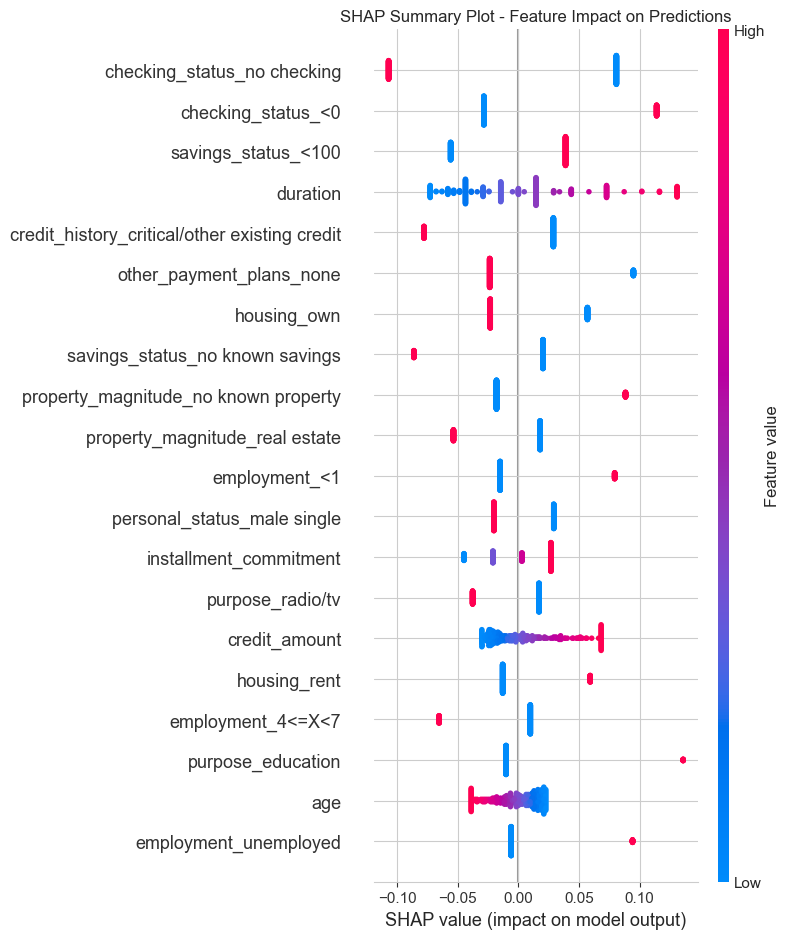

In [13]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_processed.columns, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Predictions')
plt.tight_layout()

shap_summary_path = "shap_summary_plot.png"
plt.savefig(shap_summary_path, dpi=150, bbox_inches='tight')
mlflow.log_artifact(shap_summary_path)
plt.show()

# 3. Fairness Analysis & Error Analysis

In [14]:
# Load original data for fairness analysis
from sklearn.datasets import fetch_openml
credit_data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df_original = credit_data.data.copy()
df_original['target'] = credit_data.target

# Extract test set sensitive attributes
df_test_sensitive = df_original.loc[y_test.index].copy()
df_test_sensitive['prediction'] = y_test_pred_tuned
df_test_sensitive['actual'] = y_test.values
df_test_sensitive['pred_proba'] = y_test_pred_proba_tuned

print("✓ Fairness analysis data prepared")

✓ Fairness analysis data prepared


In [15]:
# Age-based fairness analysis
if 'age' in df_test_sensitive.columns:
    df_test_sensitive['age_group'] = pd.cut(
        df_test_sensitive['age'], 
        bins=[0, 25, 35, 50, 100], 
        labels=['18-25', '26-35', '36-50', '50+']
    )
    
    print("=== Fairness Analysis by Age Group ===\n")
    for group in df_test_sensitive['age_group'].cat.categories:
        subset = df_test_sensitive[df_test_sensitive['age_group'] == group]
        if len(subset) > 0:
            approval_rate = (subset['prediction'] == 0).mean()
            avg_proba = subset['pred_proba'].mean()
            print(f"{group}: {len(subset)} applicants, Approval: {approval_rate:.2%}, Avg risk: {avg_proba:.2%}")
    
    # Chi-square test
    contingency = pd.crosstab(df_test_sensitive['age_group'], df_test_sensitive['prediction'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\nChi-square statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("⚠️ Significant difference detected across age groups")
    else:
        print("✓ No significant difference across age groups")

=== Fairness Analysis by Age Group ===

18-25: 66 applicants, Approval: 36.36%, Avg risk: 51.80%
26-35: 105 applicants, Approval: 47.62%, Avg risk: 51.06%
36-50: 90 applicants, Approval: 62.22%, Avg risk: 47.65%
50+: 39 applicants, Approval: 53.85%, Avg risk: 48.37%

Chi-square statistic: 10.7429
P-value: 0.0132
⚠️ Significant difference detected across age groups


## Error Analysis

=== ERROR ANALYSIS ===

False Positives (Type I): 73 cases
  Impact: Rejecting creditworthy applicants
  Avg probability: 0.5491

False Negatives (Type II): 14 cases
  Impact: Approving risky applicants
  Avg probability: 0.4527


C:\Users\Alala\AppData\Local\Temp\ipykernel_21832\128331971.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_rates = errors_df.groupby('prob_bin').apply(lambda x: (x['actual'] != x['predicted']).mean())
C:\Users\Alala\AppData\Local\Temp\ipykernel_21832\128331971.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_rates = errors_df.groupby('prob_bin').apply(lambda x: (x['actual'] != x['predicted']).mean())


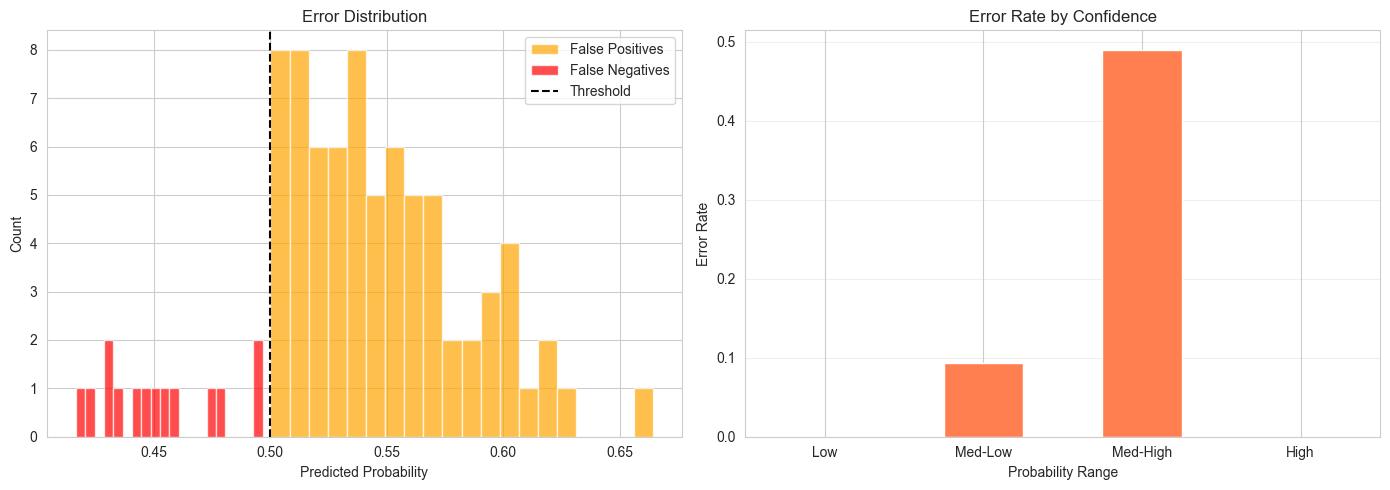

In [16]:
# Identify errors
errors_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred_tuned,
    'probability': y_test_pred_proba_tuned
})

false_positives = errors_df[(errors_df['actual'] == 0) & (errors_df['predicted'] == 1)]
false_negatives = errors_df[(errors_df['actual'] == 1) & (errors_df['predicted'] == 0)]

print("=== ERROR ANALYSIS ===\n")
print(f"False Positives (Type I): {len(false_positives)} cases")
print(f"  Impact: Rejecting creditworthy applicants")
print(f"  Avg probability: {false_positives['probability'].mean():.4f}")

print(f"\nFalse Negatives (Type II): {len(false_negatives)} cases")
print(f"  Impact: Approving risky applicants")
print(f"  Avg probability: {false_negatives['probability'].mean():.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(false_positives['probability'], bins=20, alpha=0.7, label='False Positives', color='orange')
axes[0].hist(false_negatives['probability'], bins=20, alpha=0.7, label='False Negatives', color='red')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Error Distribution')
axes[0].legend()

bins = [0, 0.3, 0.5, 0.7, 1.0]
labels = ['Low', 'Med-Low', 'Med-High', 'High']
errors_df['prob_bin'] = pd.cut(errors_df['probability'], bins=bins, labels=labels)
error_rates = errors_df.groupby('prob_bin').apply(lambda x: (x['actual'] != x['predicted']).mean())

error_rates.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Probability Range')
axes[1].set_ylabel('Error Rate')
axes[1].set_title('Error Rate by Confidence')
axes[1].set_xticklabels(labels, rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Business Impact Analysis

In [17]:
# Business metrics
avg_loan_amount = 5000
profit_margin = 0.10

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_tuned).ravel()

revenue_approved = tn * avg_loan_amount * profit_margin
loss_defaults = fn * avg_loan_amount
opportunity_cost = fp * avg_loan_amount * profit_margin
savings_rejected = tp * avg_loan_amount

net_benefit = revenue_approved - loss_defaults

print("=== BUSINESS IMPACT ANALYSIS ===\n")
print(f"Test Set: {len(y_test)} applicants\n")
print(f"  ✓ Correct approvals: {tn}")
print(f"  ✗ Wrong rejections: {fp}")
print(f"  ✗ Wrong approvals: {fn}")
print(f"  ✓ Correct rejections: {tp}\n")
print(f"Revenue from approved: ${revenue_approved:,.2f}")
print(f"Loss from defaults: -${loss_defaults:,.2f}")
print(f"Opportunity cost: -${opportunity_cost:,.2f}")
print(f"\nNET BENEFIT: ${net_benefit:,.2f}")
print(f"ROI: {(net_benefit / (avg_loan_amount * (tn + fn))) * 100:.2f}%")

mlflow.log_metric("net_benefit", net_benefit)
mlflow.log_metric("opportunity_cost", opportunity_cost)

=== BUSINESS IMPACT ANALYSIS ===

Test Set: 300 applicants

  ✓ Correct approvals: 137
  ✗ Wrong rejections: 73
  ✗ Wrong approvals: 14
  ✓ Correct rejections: 76

Revenue from approved: $68,500.00
Loss from defaults: -$70,000.00
Opportunity cost: -$36,500.00

NET BENEFIT: $-1,500.00
ROI: -0.20%


# 4. Model Deployment & Monitoring (12 marks)

In [18]:
# Save model artifacts
model_path = "credit_risk_model.pkl"
scaler_path = "scaler.pkl"
features_path = "feature_names.json"
metadata_path = "model_metadata.json"

joblib.dump(best_logreg, model_path)
joblib.dump(scaler, scaler_path)

with open(features_path, 'w') as f:
    json.dump(X_processed.columns.tolist(), f)

metadata = {
    "model_type": "Logistic Regression",
    "n_features": X_train_scaled.shape[1],
    "test_auc": float(test_auc_tuned),
    "test_accuracy": float(test_accuracy_tuned),
    "trained_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "hyperparameters": grid_search.best_params_
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

mlflow.end_run()

print("✓ Model artifacts saved")
print("✓ MLflow run completed")

✓ Model artifacts saved
✓ MLflow run completed


## Create Deployment Files

In [19]:
# Create FastAPI app.py
fastapi_code = '''from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import json
import numpy as np

app = FastAPI(title="Credit Risk API")

model = joblib.load("credit_risk_model.pkl")
scaler = joblib.load("scaler.pkl")

with open("feature_names.json") as f:
    feature_names = json.load(f)

class CreditApp(BaseModel):
    features: dict

@app.get("/")
def root():
    return {"message": "Credit Risk Prediction API"}

@app.post("/predict")
def predict(app: CreditApp):
    features = np.array([app.features.get(f, 0) for f in feature_names]).reshape(1, -1)
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0, 1]
    return {
        "risk_level": "High" if prediction == 1 else "Low",
        "probability": float(probability)
    }
'''

with open("app.py", "w") as f:
    f.write(fastapi_code)

print("✓ app.py created")

✓ app.py created


In [20]:
# Create Dockerfile
dockerfile = '''FROM python:3.9-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py credit_risk_model.pkl scaler.pkl feature_names.json .
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

with open("Dockerfile", "w") as f:
    f.write(dockerfile)

# Create requirements.txt
requirements = '''fastapi==0.104.1
uvicorn[standard]==0.24.0
pydantic==2.5.0
scikit-learn==1.3.2
numpy==1.24.3
joblib==1.3.2
'''

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("✓ Dockerfile and requirements.txt created")
print("\nDeployment commands:")
print("  docker build -t credit-risk-api .")
print("  docker run -p 8000:8000 credit-risk-api")

✓ Dockerfile and requirements.txt created

Deployment commands:
  docker build -t credit-risk-api .
  docker run -p 8000:8000 credit-risk-api


---

## Part B Complete ✓

### Summary:
- Model selected and justified (Logistic Regression)
- MLflow experiment tracking implemented
- Hyperparameter tuning performed
- SHAP explainability added
- Cross-validation completed
- Fairness analysis conducted
- Error analysis performed
- Business impact calculated
- Deployment files created (FastAPI + Docker)
